In [5]:
def generate_correlated_data(n_months: int = 36, seed: int = 42):
    """
    Generates 36 months of synthetic transactions with:
    - Month-to-month autocorrelation (spending habits persist)
    - Seasonal patterns (higher spend in Oct-Dec festive season)
    - Gradual inflation trend (1% per month)
    - No future dates
    """
    rng = np.random.default_rng(seed)

    end_date   = pd.Timestamp.today().normalize()
    start_date = end_date - pd.DateOffset(months=n_months)

    # (category, type, base_amount, txns_per_month, autocorr, seasonality_months)
    # autocorr: 0=random each month, 0.9=very sticky (changes slowly)
    # seasonality_months: list of high-spend months (1-12), empty=no seasonality
    categories = [
        ("Rent & Housing",  "fixed",    12000, 1,  0.99, []),
        ("Loan / EMI",      "fixed",     5000, 1,  0.99, []),
        ("Insurance",       "fixed",     2000, 1,  0.98, [3, 9]),       # annual premium months
        ("Subscriptions",   "fixed",      650, 3,  0.95, []),
        ("Fitness",         "fixed",     1000, 1,  0.97, []),
        ("Utilities",       "variable",  1800, 2,  0.80, [5, 6, 11]),   # summer + winter bills
        ("Groceries",       "variable",  1200, 6,  0.75, [10, 11, 12]), # festive season
        ("Food & Dining",   "variable",   400, 8,  0.65, [10, 11, 12]),
        ("Transport",       "variable",   250, 9,  0.70, []),
        ("Investments",     "variable",  3000, 2,  0.85, [3, 4]),       # tax-saving months
        ("Shopping",        "variable",   900, 4,  0.55, [10, 11, 12]),
        ("Healthcare",      "irregular",  500, 1,  0.40, [1, 7]),       # seasonal illness
        ("Entertainment",   "irregular",  600, 2,  0.50, [10, 11, 12]),
        ("Education",       "irregular",  900, 1,  0.60, [6, 7]),       # academic year
        ("Travel",          "irregular", 4000, 0,  0.20, [4, 5, 10]),   # holiday months
        ("Gifts & Charity", "irregular",  600, 0,  0.30, [10, 11, 12]),
        ("Cash Withdrawal", "variable",  1000, 2,  0.60, []),
    ]

    # Each category tracks its "current level" — autocorrelation means
    # next month's base = weighted average of this month's actual + long-run base
    current_levels = {cat[0]: float(cat[2]) for cat in categories}

    rows = []

    for month_offset in range(n_months):
        month_start = start_date + pd.DateOffset(months=month_offset)
        month_end   = month_start + pd.DateOffset(months=1) - pd.DateOffset(days=1)
        month_end   = min(month_end, end_date)
        month_dates = pd.date_range(month_start, month_end, freq="D")

        if len(month_dates) == 0:
            continue

        current_month = month_start.month
        # Inflation: prices grow ~1% per month over 3 years
        inflation = 1 + (month_offset * 0.008)

        # Salary (grows slowly over time)
        salary = float(rng.integers(45000, 55000)) * (1 + month_offset * 0.003)
        rows.append({
            "date":        month_start + pd.Timedelta(days=1),
            "description": "salary credit",
            "amount":      round(salary, 2),
            "category":    "Income",
            "type":        "credit",
        })

        for cat_name, cat_type, base_amt, monthly_freq, autocorr, seasonal_months in categories:

            # Seasonal multiplier: 1.3x in peak months, 1.0x otherwise
            seasonal_mult = 1.3 if current_month in seasonal_months else 1.0

            # Autocorrelated level: blend last month's level with long-run base
            prev_level = current_levels[cat_name]
            long_run   = base_amt * inflation * seasonal_mult
            # Noise around the current level
            noise_std  = 0.15 if cat_type == "fixed" else 0.35 if cat_type == "variable" else 0.55
            shock      = float(rng.normal(0, noise_std))
            new_level  = autocorr * prev_level + (1 - autocorr) * long_run * (1 + shock)
            new_level  = max(new_level, base_amt * 0.1)  # floor at 10% of base
            current_levels[cat_name] = new_level

            # Travel and Gifts: only appear in seasonal months or rarely
            if cat_type == "irregular" and monthly_freq == 0:
                prob = 0.55 if current_month in seasonal_months else 0.10
                if rng.random() > prob:
                    continue
                txn_count = int(rng.integers(1, 3))
            else:
                txn_count = max(1, int(monthly_freq * (1 + rng.normal(0, 0.15))))

            # Spread transactions across the month
            txn_dates = [month_dates[i] for i in
                         sorted(rng.choice(len(month_dates), txn_count, replace=False))]

            # Split monthly total across transactions (not equal split — realistic)
            if txn_count == 1:
                amounts = [new_level]
            else:
                splits = rng.dirichlet(np.ones(txn_count))
                amounts = [new_level * s for s in splits]

            for txn_date, amount in zip(txn_dates, amounts):
                rows.append({
                    "date":        txn_date,
                    "description": cat_name.lower(),
                    "amount":      round(max(10.0, float(amount)), 2),
                    "category":    cat_name,
                    "type":        "debit",
                })

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    return df


# Generate 36 months
df_new = generate_correlated_data(n_months=36, seed=42)
df_new.to_csv("../data/transactions_raw.csv", index=False)

print(f"Generated {len(df_new):,} transactions")
print(f"Date range: {df_new['date'].min().date()}  to  {df_new['date'].max().date()}")
print(f"\nMonths of data per category:")
monthly_check = (
    df_new[df_new["type"]=="debit"]
    .groupby("category")["date"]
    .apply(lambda x: x.dt.to_period("M").nunique())
    .sort_values(ascending=False)
)
print(monthly_check.to_string())

Generated 1,459 transactions
Date range: 2023-03-28  to  2026-03-27

Months of data per category:
category
Food & Dining      37
Transport          37
Groceries          37
Shopping           37
Entertainment      36
Subscriptions      36
Cash Withdrawal    35
Investments        35
Insurance          34
Utilities          34
Loan / EMI         34
Rent & Housing     33
Education          33
Fitness            32
Healthcare         31
Gifts & Charity     9
Travel              7


18:46:50 - cmdstanpy - INFO - Chain [1] start processing


Expense transactions: 1,423
Date range: 2023-03-28 to 2026-03-27

Categories to forecast:
category
Transport          298
Food & Dining      265
Groceries          189
Shopping           129
Subscriptions       88
Entertainment       59
Cash Withdrawal     53
Utilities           53
Investments         52
Loan / Emi          36
Education           36
Rent & Housing      36
Fitness             36
Insurance           36
Healthcare          36
Gifts & Charity     12
Travel               9
Name: count, dtype: int64
  Shopping                  37 months  total=₹41,401
  Transport                 37 months  total=₹10,329
  Groceries                 37 months  total=₹50,536
  Food & Dining             37 months  total=₹17,808
  Cash Withdrawal           35 months  total=₹39,771
  Entertainment             36 months  total=₹27,331
  Investments               35 months  total=₹129,027
  Subscriptions             36 months  total=₹25,346
  Loan / Emi                34 months  total=₹183,511
  Edu

18:46:50 - cmdstanpy - INFO - Chain [1] done processing
18:46:50 - cmdstanpy - INFO - Chain [1] start processing


  Shopping                   MAE=   ₹1166  MAPE= 100.0%  RMSE=   ₹1168


18:46:51 - cmdstanpy - INFO - Chain [1] done processing
18:46:51 - cmdstanpy - INFO - Chain [1] start processing


...

  Insurance                  MAE=   ₹3200  MAPE= 145.3%  RMSE=   ₹3712


18:47:01 - cmdstanpy - INFO - Chain [1] done processing
18:47:01 - cmdstanpy - INFO - Chain [1] start processing
18:47:01 - cmdstanpy - INFO - Chain [1] done processing


  Healthcare                 MAE=    ₹609  MAPE=  96.5%  RMSE=    ₹615
  Travel                     MAE=   ₹4628  MAPE=  84.9%  RMSE=   ₹4640


18:47:02 - cmdstanpy - INFO - Chain [1] start processing
18:47:02 - cmdstanpy - INFO - Chain [1] done processing


  Gifts & Charity            MAE=    ₹309  MAPE=  25.9%  RMSE=    ₹309

17 models trained successfully
       category   mape reliability  show_in_ui
  Entertainment  13.21        high        True
Gifts & Charity  25.95        high        True
  Food & Dining  26.66        high        True
        Fitness  41.90      medium        True
Cash Withdrawal  53.10      medium        True
      Transport  58.64      medium        True
    Investments  76.62         low        True
      Utilities  79.10         low        True
         Travel  84.86         low        True
      Education  95.51         low        True
     Healthcare  96.46         low        True
  Subscriptions  99.24         low        True
 Rent & Housing 100.00  unreliable       False
       Shopping 100.00  unreliable       False
     Loan / Emi 134.46  unreliable       False
      Insurance 145.27  unreliable       False
      Groceries 249.52  unreliable       False


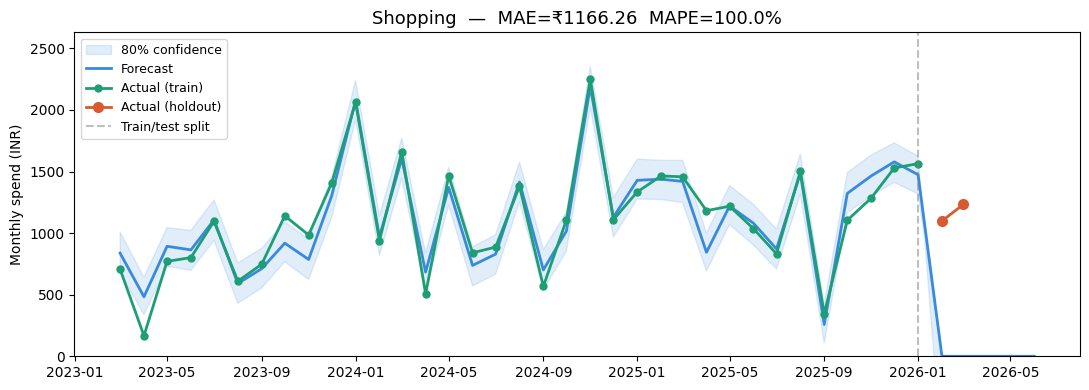

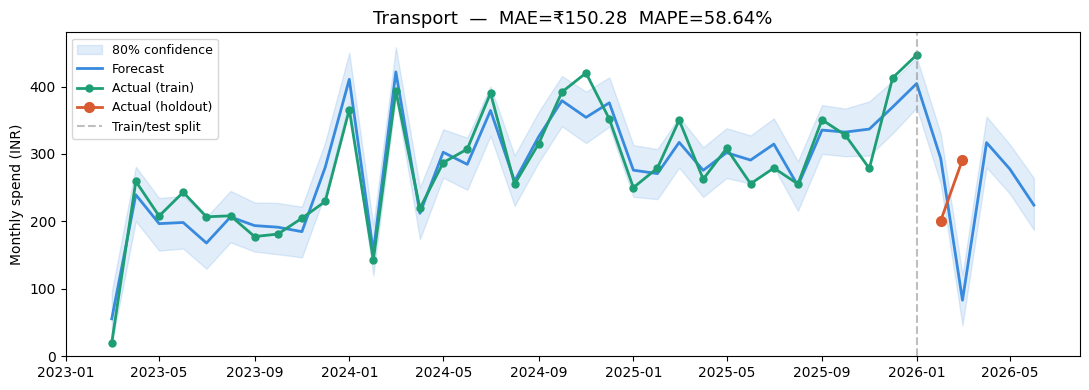

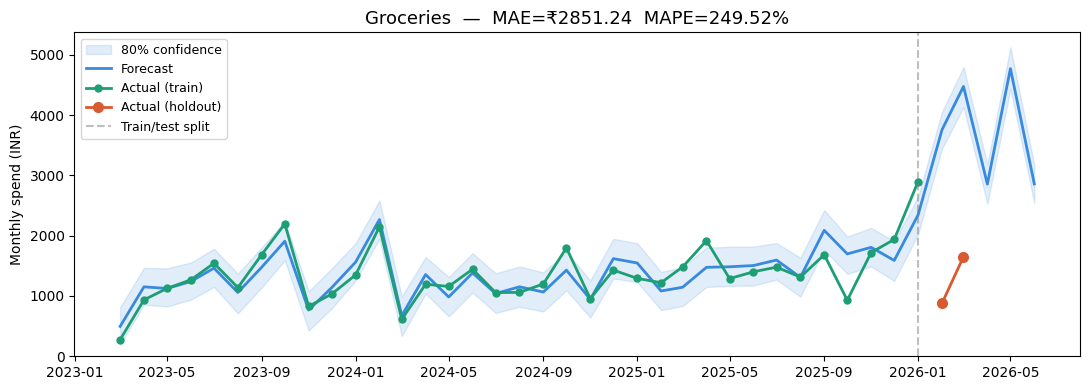

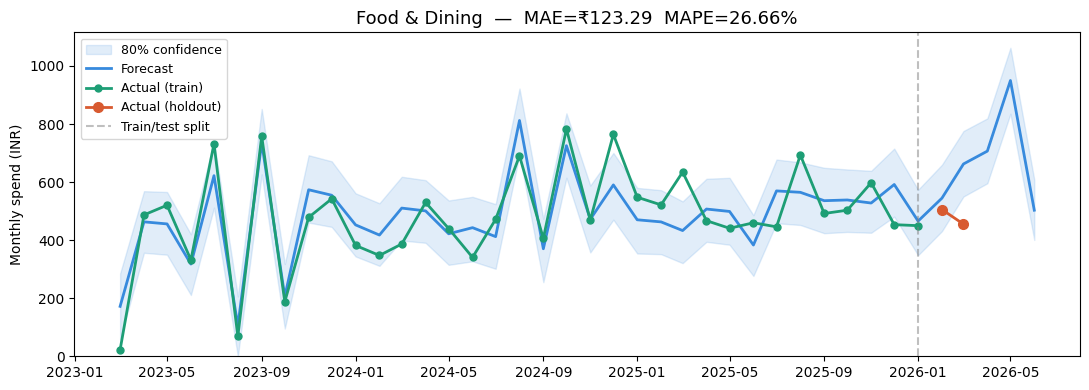

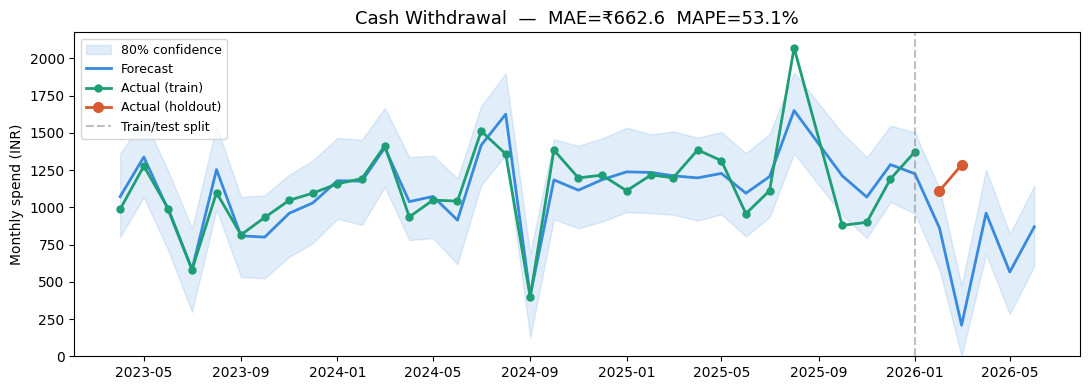

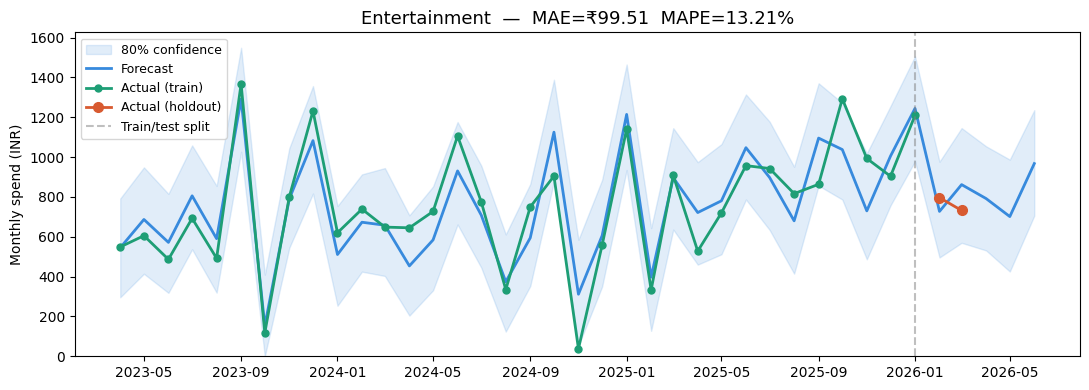

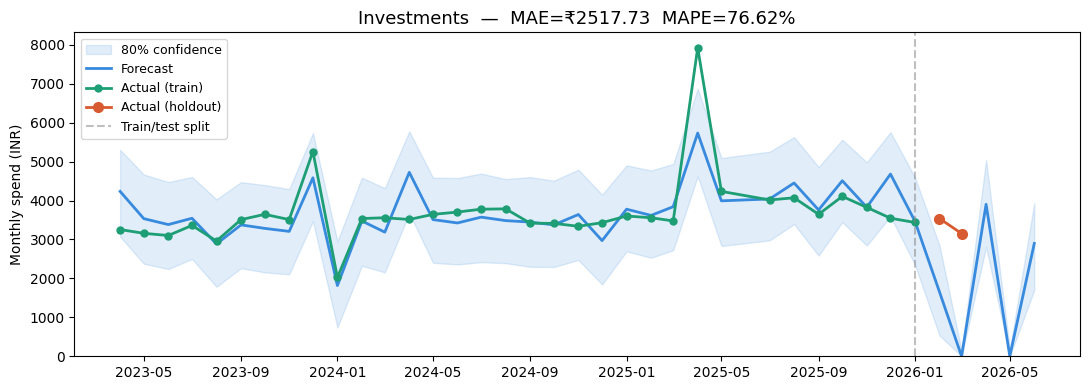

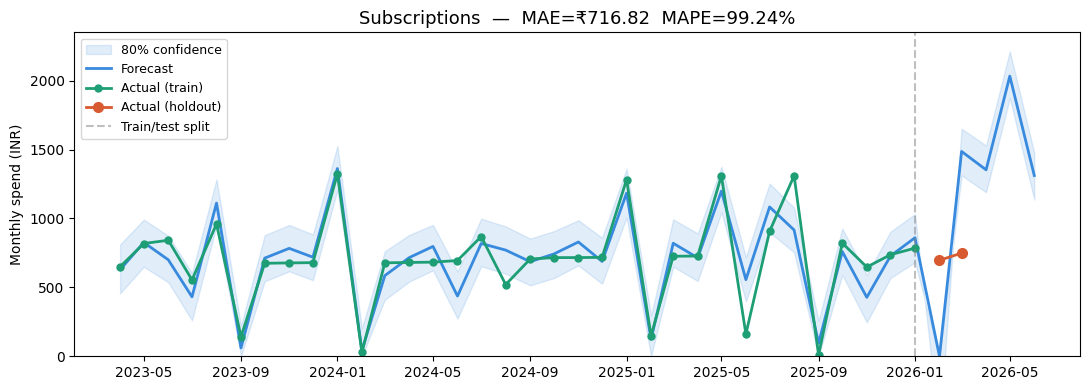

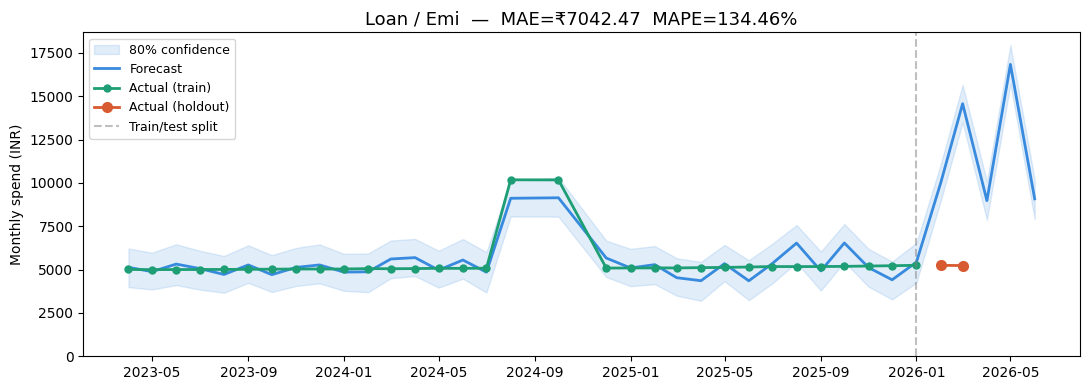

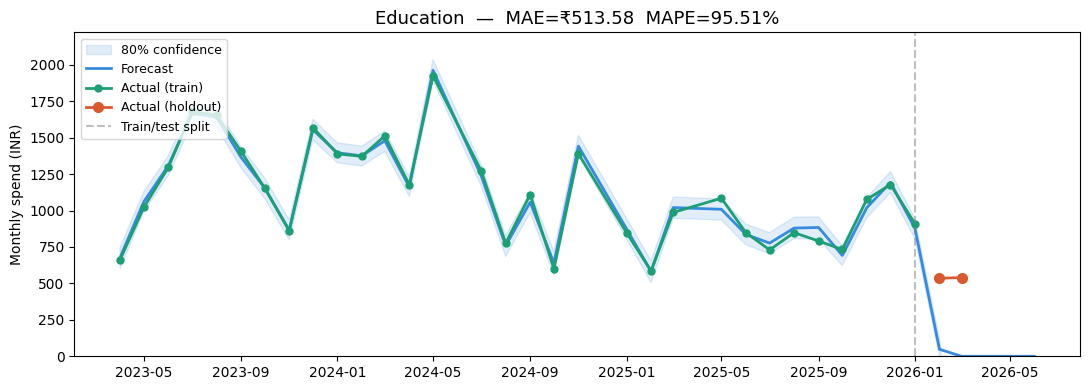

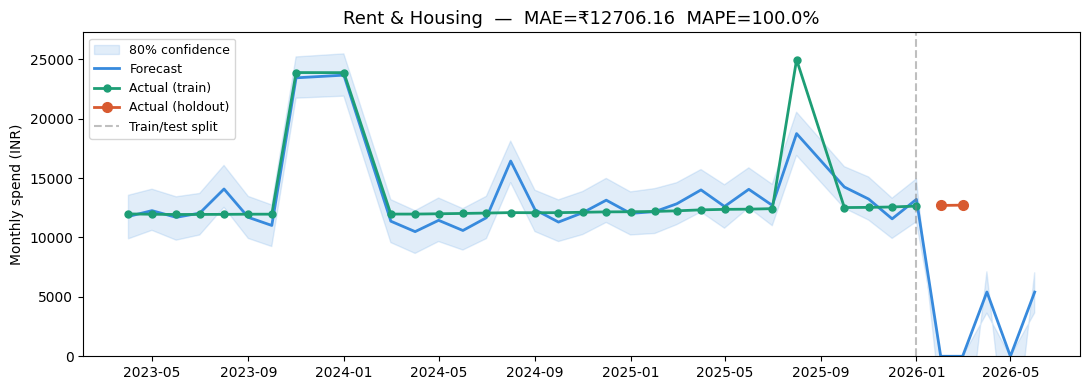

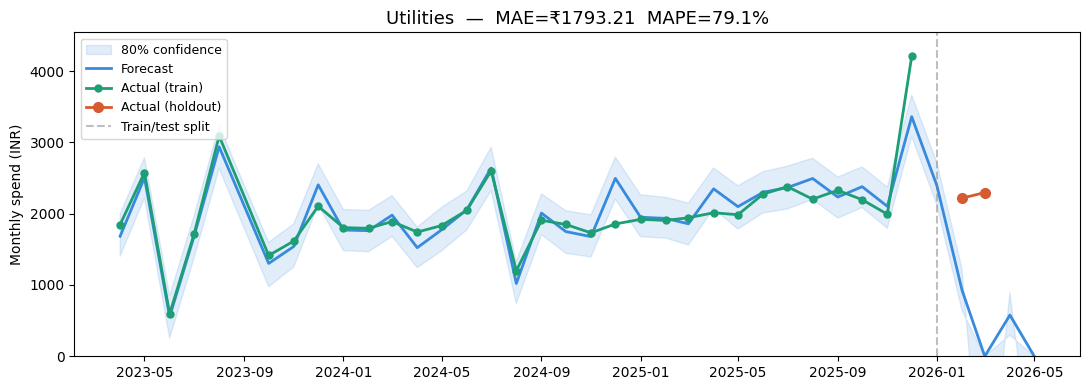

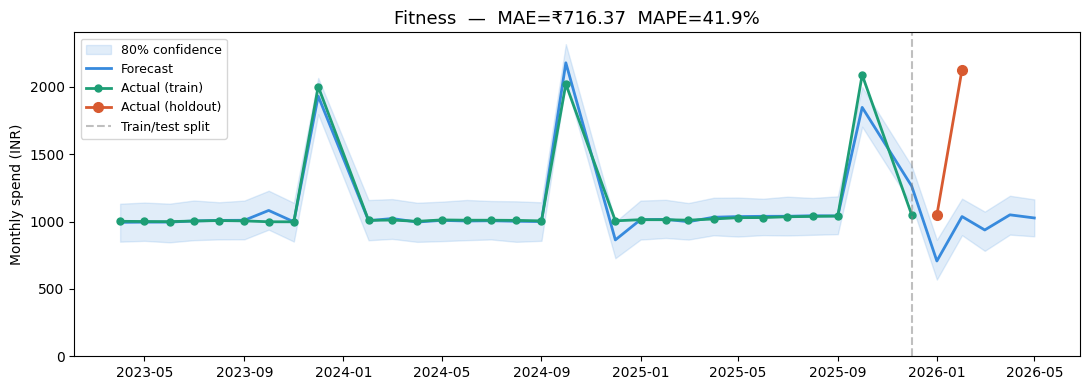

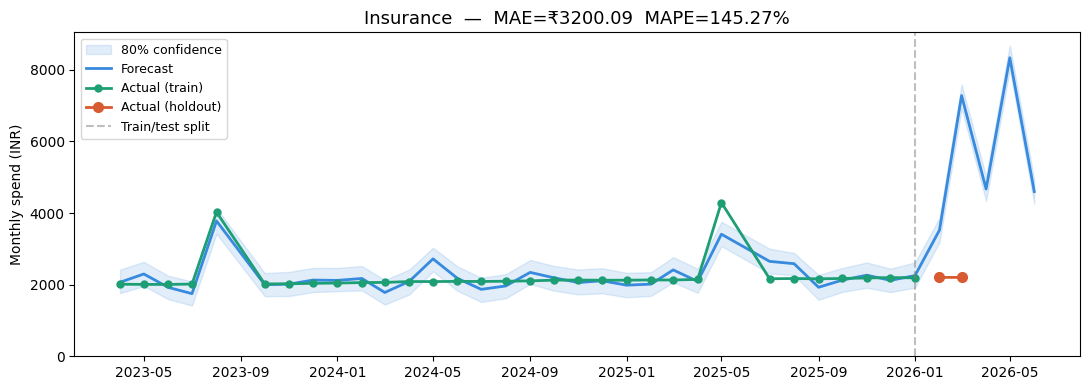

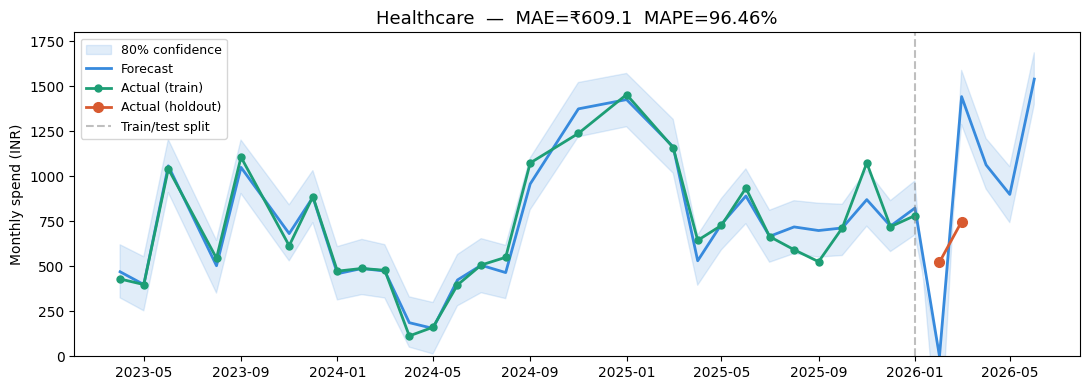

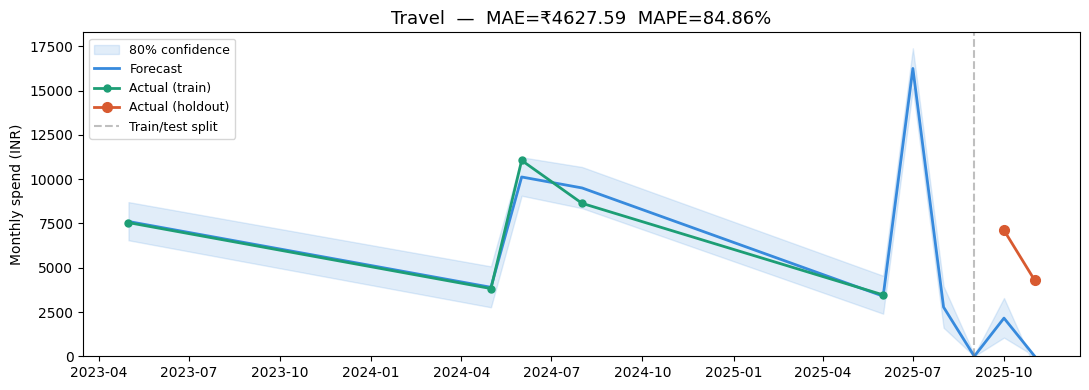

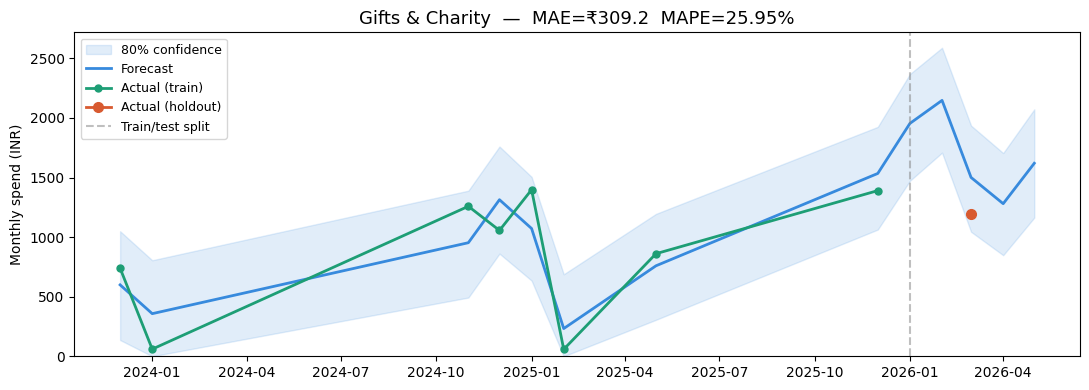


Food & Dining  [prophet]
  2026-02  ₹5,791  (₹5,789 – ₹5,792)
  2026-03  ₹0  (₹0 – ₹0)
  2026-04  ₹0  (₹0 – ₹0)

Rent & Housing  [average_fallback]
  2026-04  ₹12,684  (₹10,782 – ₹14,587)
  2026-05  ₹12,684  (₹10,782 – ₹14,587)
  2026-06  ₹12,684  (₹10,782 – ₹14,587)

Entertainment  [prophet]
  2026-02  ₹924  (₹914 – ₹936)
  2026-03  ₹1,298  (₹1,266 – ₹1,335)
  2026-04  ₹0  (₹0 – ₹0)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import joblib
from pathlib import Path

Path("../backend/models/prophet").mkdir(parents=True, exist_ok=True)
Path("../data/charts/forecast").mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/clean_transactions.csv", parse_dates=["date"])
expenses = df[df["txn_type"] == "debit"].copy()

print(f"Expense transactions: {len(expenses):,}")
print(f"Date range: {expenses['date'].min().date()} to {expenses['date'].max().date()}")
print(f"\nCategories to forecast:")
print(expenses["category"].value_counts())

def get_monthly_series(expenses_df, category):
    cat_df = expenses_df[expenses_df["category"] == category].copy()
    
    monthly = (
        cat_df
        .groupby(cat_df["date"].dt.to_period("M"))["amount"]
        .sum()
        .reset_index()
    )
    monthly["date"] = monthly["date"].dt.to_timestamp()
    monthly = monthly.rename(columns={"date": "ds", "amount": "y"})
    monthly = monthly.sort_values("ds").reset_index(drop=True)
    
    # Winsorize: clip anything above 3x median (handles outlier months)
    median_val = monthly["y"].median()
    monthly["y"] = monthly["y"].clip(upper=median_val * 3)
    
    # Ensure no zeros or negatives (Prophet handles them badly)
    monthly["y"] = monthly["y"].clip(lower=1)
    
    return monthly

# Check which categories have enough data (min 6 months)
categories = expenses["category"].unique()
valid_categories = []

for cat in categories:
    series = get_monthly_series(expenses, cat)
    if len(series) >= 6:
        valid_categories.append(cat)
        print(f"  {cat:<25} {len(series)} months  total=₹{series['y'].sum():,.0f}")
    else:
        print(f"  {cat:<25} SKIPPED (only {len(series)} months of data)")

print(f"\n{len(valid_categories)} categories will be forecasted")

# Hold out last 2 months for evaluation
HOLDOUT_MONTHS = 2

# Classify categories by behavior
FIXED_CATEGORIES    = {"Rent & Housing", "Insurance", "Loan / EMI", "Subscriptions"}
VARIABLE_CATEGORIES = {"Food & Dining", "Groceries", "Transport", "Shopping", "Utilities"}
IRREGULAR_CATEGORIES = {"Entertainment", "Healthcare", "Education", "Gifts & Charity",
                         "Investments", "Cash Withdrawal", "Fitness", "Travel"}

def get_prophet_config(category):
    if category in FIXED_CATEGORIES:
        return dict(
            changepoint_prior_scale = 0.001,  # almost no change allowed
            seasonality_mode        = "additive",
            interval_width          = 0.80,
        )
    elif category in VARIABLE_CATEGORIES:
        return dict(
            changepoint_prior_scale = 0.05,
            seasonality_mode        = "multiplicative",
            interval_width          = 0.80,
        )
    else:  # irregular
        return dict(
            changepoint_prior_scale = 0.1,   # more flexible
            seasonality_mode        = "additive",
            interval_width          = 0.95,  # wider bands — honest about uncertainty
        )
        
def train_prophet(series_df, category_name):
    cutoff = series_df["ds"].max() - pd.DateOffset(months=HOLDOUT_MONTHS)
    train  = series_df[series_df["ds"] <= cutoff].copy()
    test   = series_df[series_df["ds"] >  cutoff].copy()
    
    if len(train) < 4:
        print(f"  [SKIP] {category_name} — not enough training data")
        return None, None, None

    config = get_prophet_config(category_name)
    has_yearly = len(train) >= 12

    model = Prophet(
        yearly_seasonality  = has_yearly,
        weekly_seasonality  = False,
        daily_seasonality   = False,
        **config
    )
    model.add_seasonality(name="monthly", period=30.5, fourier_order=3)
    model.fit(train)

    future   = model.make_future_dataframe(periods=HOLDOUT_MONTHS + 3, freq="MS")
    forecast = model.predict(future)
    forecast["yhat"]       = forecast["yhat"].clip(lower=0)
    forecast["yhat_lower"] = forecast["yhat_lower"].clip(lower=0)

    metrics = {}
    if len(test) > 0:
        test_forecast = forecast[forecast["ds"].isin(test["ds"])]
        if len(test_forecast) > 0:
            actual    = test["y"].values
            predicted = test_forecast["yhat"].values[:len(actual)]

            mae  = np.mean(np.abs(actual - predicted))
            mape = np.mean(np.abs((actual - predicted) / np.maximum(actual, 1))) * 100
            rmse = np.sqrt(np.mean((actual - predicted) ** 2))
            metrics = {"mae": round(mae, 2), "mape": round(mape, 2), "rmse": round(rmse, 2)}

    return model, forecast, metrics

def reliability_label(mape):
    if mape is None:    return "unknown"
    if mape < 30:       return "high"
    if mape < 60:       return "medium"
    if mape < 100:      return "low"
    return              "unreliable"



# Train all valid categories
all_models   = {}
all_forecasts = {}
all_metrics  = {}

print("Training Prophet models...\n")
for cat in valid_categories:
    series = get_monthly_series(expenses, cat)
    model, forecast, metrics = train_prophet(series, cat)
    
    if model is not None:
        all_models[cat]    = model
        all_forecasts[cat] = forecast
        all_metrics[cat]   = metrics
        
        mae_str  = f"₹{metrics['mae']:.0f}"  if metrics.get('mae')  is not None else "N/A"
        mape_str = f"{metrics['mape']:.1f}%" if metrics.get('mape') is not None else "N/A"
        rmse_str = f"₹{metrics['rmse']:.0f}" if metrics.get('rmse') is not None else "N/A"
        print(f"  {cat:<25}  MAE={mae_str:>8}  MAPE={mape_str:>7}  RMSE={rmse_str:>8}")

print(f"\n{len(all_models)} models trained successfully")

rows = []
for cat, m in all_metrics.items():
    mape = m.get("mape")
    rows.append({
        "category"    : cat,
        "mae"         : m.get("mae"),
        "mape"        : mape,
        "rmse"        : m.get("rmse"),
        "reliability" : reliability_label(mape),
        "show_in_ui"  : mape is not None and mape < 100,
    })

metrics_df = pd.DataFrame(rows).sort_values("mape")
metrics_df.to_csv("../data/forecast_metrics.csv", index=False)
print(metrics_df[["category", "mape", "reliability", "show_in_ui"]].to_string(index=False))

def plot_forecast(series_df, forecast_df, category, metrics, save=True):
    """Plot actual vs predicted with confidence bands."""
    cutoff = series_df["ds"].max() - pd.DateOffset(months=HOLDOUT_MONTHS)
    
    fig, ax = plt.subplots(figsize=(11, 4))
    
    # Confidence band
    ax.fill_between(
        forecast_df["ds"],
        forecast_df["yhat_lower"].clip(0),
        forecast_df["yhat_upper"],
        alpha=0.15, color="#378ADD", label="80% confidence"
    )
    
    # Forecast line
    ax.plot(forecast_df["ds"], forecast_df["yhat"].clip(0),
            color="#378ADD", linewidth=2, label="Forecast")
    
    # Actual data — split into train and holdout
    train_actual = series_df[series_df["ds"] <= cutoff]
    test_actual  = series_df[series_df["ds"] >  cutoff]
    
    ax.plot(train_actual["ds"], train_actual["y"],
            "o-", color="#1D9E75", linewidth=2, markersize=5, label="Actual (train)")
    
    if len(test_actual) > 0:
        ax.plot(test_actual["ds"], test_actual["y"],
                "o-", color="#D85A30", linewidth=2, markersize=7, label="Actual (holdout)")
    
    # Cutoff line
    ax.axvline(cutoff, color="gray", linestyle="--", alpha=0.5, label="Train/test split")
    
    # Labels
    mae_str  = f"MAE=₹{metrics.get('mae', 'N/A')}"
    mape_str = f"MAPE={metrics.get('mape', 'N/A')}%"
    ax.set_title(f"{category}  —  {mae_str}  {mape_str}", fontsize=13)
    ax.set_ylabel("Monthly spend (INR)")
    ax.legend(loc="upper left", fontsize=9)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    if save:
        fname = category.lower().replace(" ", "_").replace("/", "_").replace("&", "and")
        plt.savefig(f"../data/charts/forecast/{fname}.png", dpi=150)
    plt.show()
    plt.close()


# Plot all forecasts
for cat in all_models:
    series   = get_monthly_series(expenses, cat)
    forecast = all_forecasts[cat]
    metrics  = all_metrics[cat]
    plot_forecast(series, forecast, cat, metrics)

def get_smart_forecast(category, models_dir="../backend/models/prophet"):
    """
    For unreliable/fixed categories: return 3-month average instead of Prophet.
    For reliable categories: return Prophet forecast.
    This is what your FastAPI endpoint will call in Week 5.
    """
    FIXED_FALLBACK = {
        "Rent & Housing", "Loan / Emi", "Insurance",
        "Subscriptions", "Shopping", "Groceries"
    }

    metrics_df = pd.read_csv("../data/forecast_metrics.csv")
    cat_row    = metrics_df[metrics_df["category"] == category]
    is_reliable = (
        not cat_row.empty and
        cat_row.iloc[0]["show_in_ui"] and
        category not in FIXED_FALLBACK
    )

    expenses = df[df["txn_type"] == "debit"].copy()

    if is_reliable:
        # Use Prophet
        fname  = category.lower().replace(" ","_").replace("/","_").replace("&","and")
        model  = joblib.load(f"{models_dir}/{fname}.pkl")
        future = model.make_future_dataframe(periods=3, freq="MS")
        fc     = model.predict(future)
        future_only = fc[fc["ds"] > model.history["ds"].max()].head(3)
        return {
            "method": "prophet",
            "predictions": [
                {
                    "month":  str(r["ds"])[:7],
                    "amount": round(max(0, r["yhat"]), 2),
                    "lower":  round(max(0, r["yhat_lower"]), 2),
                    "upper":  round(max(0, r["yhat_upper"]), 2),
                }
                for _, r in future_only.iterrows()
            ]
        }
    else:
        # Fallback: use last 3-month average
        recent = (
            expenses[expenses["category"] == category]
            .groupby(expenses["date"].dt.to_period("M"))["amount"]
            .sum()
            .tail(3)
        )
        avg = round(float(recent.mean()), 2) if len(recent) > 0 else 0.0
        next_months = pd.date_range(
            pd.Timestamp.today().to_period("M").to_timestamp() + pd.DateOffset(months=1),
            periods=3, freq="MS"
        )
        return {
            "method": "average_fallback",
            "predictions": [
                {"month": str(m)[:7], "amount": avg, "lower": avg * 0.85, "upper": avg * 1.15}
                for m in next_months
            ]
        }


# Quick test
for cat in ["Food & Dining", "Rent & Housing", "Entertainment"]:
    result = get_smart_forecast(cat)
    print(f"\n{cat}  [{result['method']}]")
    for p in result["predictions"]:
        print(f"  {p['month']}  ₹{p['amount']:,.0f}  (₹{p['lower']:,.0f} – ₹{p['upper']:,.0f})")